# Data Cleaning & Visualization Project

## Introduction

Welcome to this data cleaning and visualization project! In this notebook, we'll walk through a typical data science workflow, starting from loading a raw dataset, cleaning it, and then performing exploratory data analysis (EDA) using various visualizations. This process is fundamental to understanding your data and preparing it for more advanced analysis or machine learning tasks.

This notebook is designed to be beginner-friendly, with clear explanations and clean code for each step.

## Project Objective

The main objective of this project is to:
1.  **Load and inspect** a given CSV dataset.
2.  **Clean** the dataset by handling missing values, removing duplicates, and identifying outliers.
3.  **Visualize** the data using various charts to understand its distribution, relationships between variables, and potential patterns or anomalies.
4.  **Extract key findings** and **business insights** from the analysis.
5.  **Save** the cleaned dataset for future use.

## 1. Import Required Libraries

First, we'll import all the necessary Python libraries that we'll use throughout this project. These include `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib.pyplot` and `seaborn` for data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Upload and Load CSV Dataset

To begin, you'll need to upload your CSV file to Google Colab. You can do this by clicking the folder icon on the left sidebar, then the 'Upload to session storage' icon. Once uploaded, replace `'your_dataset.csv'` with the actual name of your file.

In [2]:
# Load the dataset from a CSV file
# Make sure to upload your CSV file to the Colab environment first.
# Example: df = pd.read_csv('your_dataset.csv')

# For demonstration purposes, let's create a dummy dataset if no file is uploaded.
# In a real scenario, you would replace this with your actual data loading.
try:
    # Try to load a real dataset if available. Replace 'your_dataset.csv' with your file name.
    # df = pd.read_csv('your_dataset.csv')

    # If you don't have a dataset, uncomment the following lines to use a sample dataset
    data = {
        'Age': [25, 30, np.nan, 35, 40, 28, 50, 25, 30, 35, 28, 45, 60, 30, 25],
        'Salary': [50000, 60000, 55000, 70000, 80000, 52000, 90000, 50000, 60000, 70000, 52000, 85000, 100000, 60000, 50000],
        'Experience': [2, 5, 3, 8, 12, 3, 15, 2, 5, 8, 3, 10, 20, 5, 2],
        'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', 'IT', 'HR', 'IT', 'Sales', 'HR', 'IT', 'Sales', 'HR', 'IT'],
        'City': ['NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA'],
        'Rating': [4.5, 3.8, np.nan, 4.2, 3.9, 4.1, 4.8, 4.5, 3.8, 4.2, 3.9, 4.1, 4.8, 3.8, 4.5]
    }
    df = pd.DataFrame(data)
    print("Using a dummy dataset for demonstration.")

except FileNotFoundError:
    print("Error: Dataset not found. Please upload your CSV file or check the file name.")
    # Fallback to dummy data if the file is not found
    data = {
        'Age': [25, 30, np.nan, 35, 40, 28, 50, 25, 30, 35, 28, 45, 60, 30, 25],
        'Salary': [50000, 60000, 55000, 70000, 80000, 52000, 90000, 50000, 60000, 70000, 52000, 85000, 100000, 60000, 50000],
        'Experience': [2, 5, 3, 8, 12, 3, 15, 2, 5, 8, 3, 10, 20, 5, 2],
        'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', 'IT', 'HR', 'IT', 'Sales', 'HR', 'IT', 'Sales', 'HR', 'IT'],
        'City': ['NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA', 'NY', 'SF', 'LA'],
        'Rating': [4.5, 3.8, np.nan, 4.2, 3.9, 4.1, 4.8, 4.5, 3.8, 4.2, 3.9, 4.1, 4.8, 3.8, 4.5]
    }
    df = pd.DataFrame(data)
    print("Generated a dummy dataset for demonstration.")

Using a dummy dataset for demonstration.


## 3. Display Dataset Information

Before we start cleaning, it's crucial to get a good overview of our dataset. We'll look at the first and last rows, check its dimensions (shape), column names, data types, and a statistical summary to understand the data's basic characteristics.

### First 5 Rows

In [3]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Salary,Experience,Department,City,Rating
0,25.0,50000,2,HR,NY,4.5
1,30.0,60000,5,IT,SF,3.8
2,NaN,55000,3,Sales,LA,NaN
3,35.0,70000,8,IT,NY,4.2
4,40.0,80000,12,HR,SF,3.9


### Last 5 Rows

In [4]:
# Display the last 5 rows of the DataFrame
print("Last 5 rows of the dataset:")
display(df.tail())

Last 5 rows of the dataset:


,Age,Salary,Experience,Department,City,Rating
10,28.0,52000,3,HR,SF,3.9
11,45.0,85000,10,IT,LA,4.1
12,60.0,100000,20,Sales,NY,4.8
13,30.0,60000,5,HR,SF,3.8
14,25.0,50000,2,IT,LA,4.5


### Dataset Shape

In [5]:
# Display the shape of the DataFrame (rows, columns)
print(f"Dataset shape: {df.shape} (rows, columns)")

Dataset shape: (15, 6) (rows, columns)


### Column Names

In [6]:
# Display the names of all columns
print("Column names:")
print(df.columns.tolist())

Column names:
['Age', 'Salary', 'Experience', 'Department', 'City', 'Rating']


### Data Types

In [7]:
# Display the data types of each column
print("Data types:")
display(df.dtypes)

Data types:


,0
Age,float64
Salary,int64
Experience,int64
Department,object
City,object
Rating,float64


### Dataset Information

In [8]:
# Display a concise summary of the DataFrame, including data types and non-null values
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         14 non-null     float64
 1   Salary      15 non-null     int64  
 2   Experience  15 non-null     int64  
 3   Department  15 non-null     object 
 4   City        15 non-null     object 
 5   Rating      14 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 852.0+ bytes


### Statistical Summary

In [9]:
# Display descriptive statistics for numerical columns
print("Statistical summary of numerical columns:")
display(df.describe())

Statistical summary of numerical columns:


,Age,Salary,Experience,Rating
count,14.000000,15.000000,15.000000,14.000000
mean,34.714286,65600.000000,6.866667,4.207143
std,10.549725,16273.554358,5.370111,0.358339
min,25.000000,50000.000000,2.000000,3.800000
25%,28.000000,52000.000000,3.000000,3.900000
50%,30.000000,60000.000000,5.000000,4.150000
75%,38.750000,75000.000000,9.000000,4.500000
max,60.000000,100000.000000,20.000000,4.800000


## 4. Data Cleaning

Data cleaning is a critical step in any data project. It involves identifying and correcting errors and inconsistencies in the data. We'll focus on handling missing values, removing duplicate rows, and identifying outliers.

### Check Missing Values

Missing values can negatively impact our analysis. We'll check for the count and percentage of missing values in each column.

In [10]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Count of missing values per column:")
display(missing_values)

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values per column:")
display(missing_percentage)

Count of missing values per column:


,0
Age,1
Salary,0
Experience,0
Department,0
City,0
Rating,1



Percentage of missing values per column:


,0
Age,6.666667
Salary,0.000000
Experience,0.000000
Department,0.000000
City,0.000000
Rating,6.666667


### Handle Missing Values

Based on the analysis of missing values, we can choose different strategies to handle them:
-   **Dropping rows/columns**: If a column has too many missing values or if there are few rows with missing values that won't significantly impact the dataset size.
-   **Imputation**: Filling missing values with a calculated value (e.g., mean, median, mode) for numerical columns, or a specific category for categorical columns.

For numerical columns like 'Age' and 'Rating', we'll fill missing values with the median to avoid skewing the distribution with extreme values (which mean might be sensitive to). For categorical columns (if any had missing values), we might fill them with the mode or a placeholder like 'Unknown'.

In [11]:
# Handle missing values for numerical columns by imputing with the median
for col in ['Age', 'Rating']:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' filled with median: {median_val}")

# Verify that missing values have been handled
print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values in 'Age' filled with median: 30.0
Missing values in 'Rating' filled with median: 4.15

Missing values after handling:


/tmp/ipykernel_1790/2977264580.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


,0
Age,0
Salary,0
Experience,0
Department,0
City,0
Rating,0


### Find and Remove Duplicate Rows

Duplicate rows can lead to biased analyses. We'll identify and remove them to ensure each observation is unique.

In [12]:
# Check for duplicate rows
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"{duplicate_rows_count} duplicate rows removed.")
else:
    print("No duplicate rows found.")

# Verify the number of rows after removing duplicates
print(f"\nDataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 0
No duplicate rows found.

Dataset shape after removing duplicates: (15, 6)


### Detect Outliers using Boxplots

Outliers are data points that significantly differ from other observations. Boxplots are excellent tools for visualizing the distribution of numerical data and detecting potential outliers. An outlier is typically defined as a point that falls outside 1.5 times the Interquartile Range (IQR) below the first quartile or above the third quartile.

Detecting outliers using Boxplots for numerical columns:


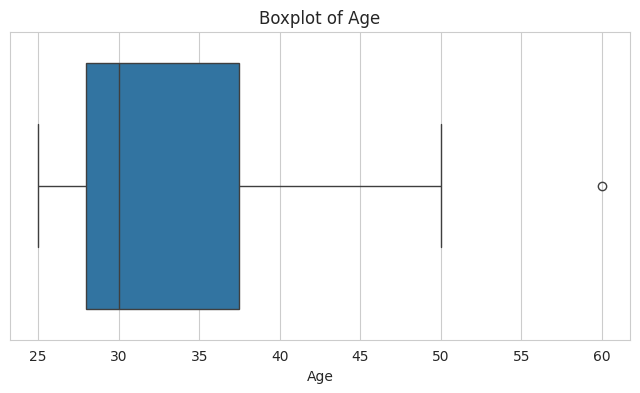

Potential outliers in 'Age':
     Age
12  60.0

--------------------------------------------------



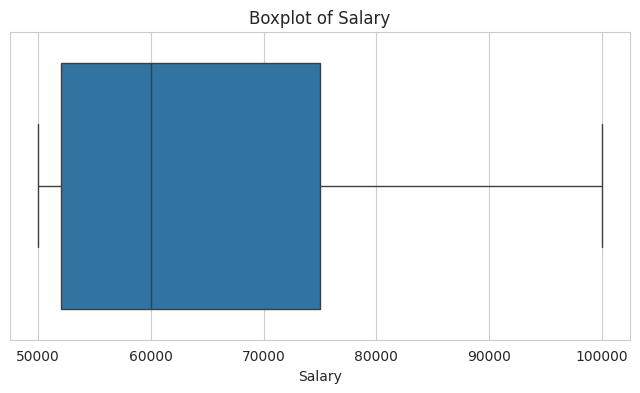

No significant outliers detected in 'Salary'.

--------------------------------------------------



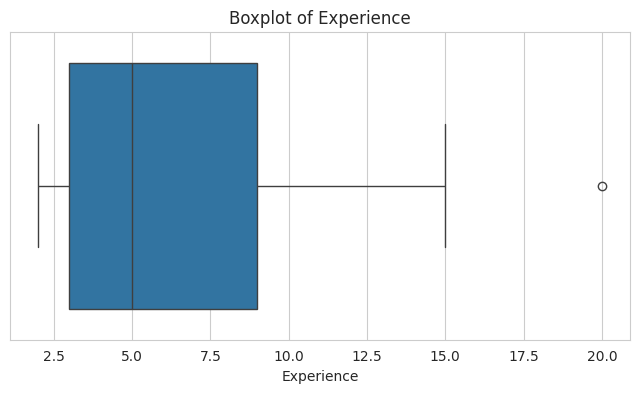

Potential outliers in 'Experience':
    Experience
12          20

--------------------------------------------------



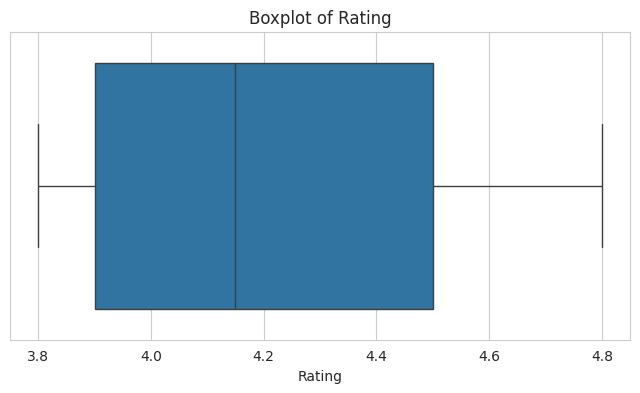

No significant outliers detected in 'Rating'.

--------------------------------------------------



In [13]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Detecting outliers using Boxplots for numerical columns:")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

    # Optional: Quantile-based outlier detection for demonstration
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Potential outliers in '{col}':\n{outliers[[col]]}")
    else:
        print(f"No significant outliers detected in '{col}'.")
    print("\n" + "-"*50 + "\n")

# For simplicity in this beginner notebook, we will just detect outliers
# and not remove them, as outlier treatment can be complex and context-dependent.
# If you choose to remove them, you might use: df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))] for each column.


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often with visual methods. It helps in understanding the data, identifying patterns, and formulating hypotheses. We will create various charts to visualize our cleaned data.

### Histogram: Distribution of Age

A histogram displays the distribution of a numerical variable. It shows how often each value (or range of values) appears in the dataset.

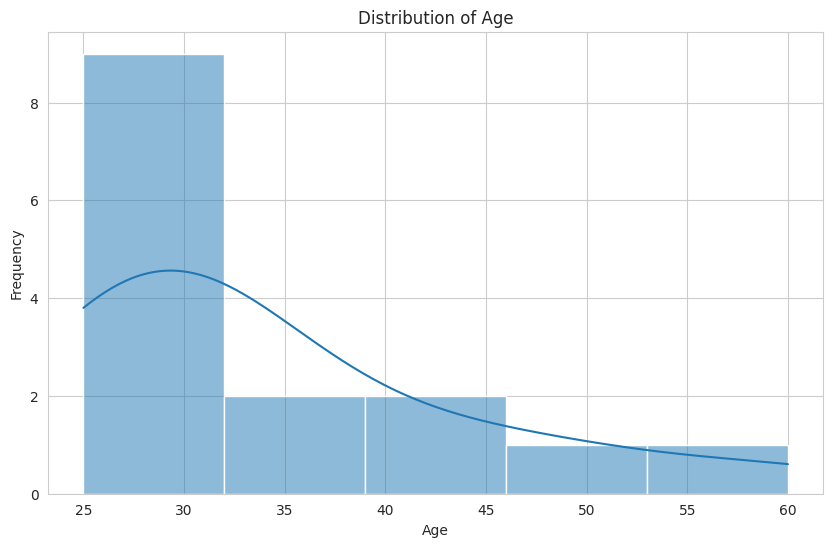

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=5, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

This histogram shows the frequency of different age groups in our dataset. The `kde` (Kernel Density Estimate) line provides a smoothed representation of the distribution. It appears that the dataset has a relatively young age distribution, with peaks around 25-30 and then another around 35-40.

### Count Plot: Department Distribution

A count plot shows the counts of observations in each category of a categorical variable. It's useful for understanding the distribution of categorical data.

/tmp/ipykernel_1790/2473365085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Department', data=df, palette='viridis')


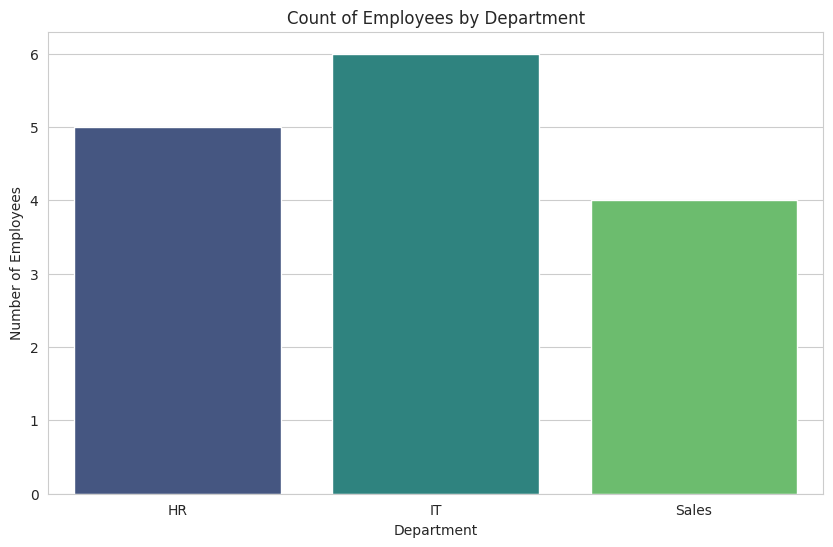

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', data=df, palette='viridis')
plt.title('Count of Employees by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.show()

The count plot illustrates the number of employees in each department. It shows that 'IT', 'HR', and 'Sales' departments have a similar number of employees in this sample dataset.

### Bar Chart: Average Salary by Department

A bar chart is used to compare values across different categories. Here, we'll visualize the average salary for each department.

/tmp/ipykernel_1790/3374733863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Salary', data=df, estimator=np.mean, palette='plasma')


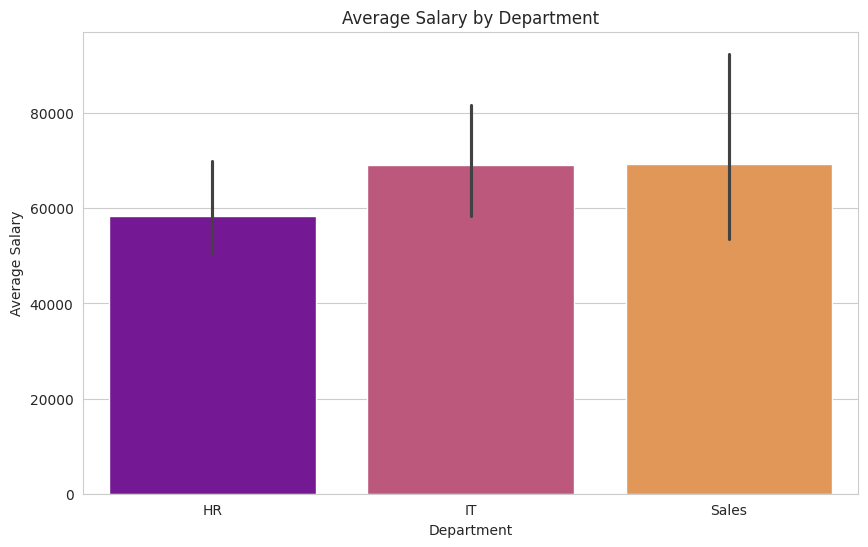

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Salary', data=df, estimator=np.mean, palette='plasma')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

This bar chart displays the average salary for employees in each department. It indicates that, in our sample, the IT department has the highest average salary, followed by Sales and HR.

### Box Plot: Salary Distribution by Department

While a bar chart shows the average, a box plot provides a more detailed view of the distribution (median, quartiles, and potential outliers) of a numerical variable across different categories.

/tmp/ipykernel_1790/2122647801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='Salary', data=df, palette='cividis')


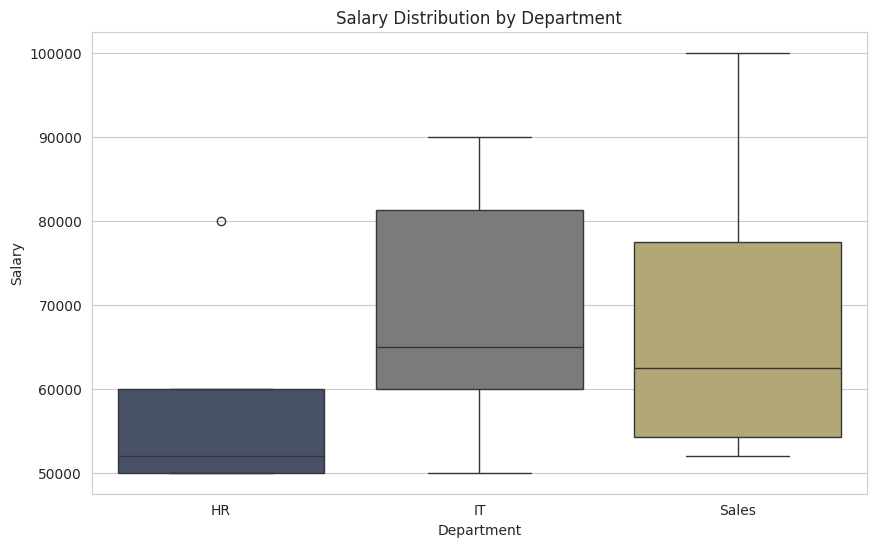

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='Salary', data=df, palette='cividis')
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

The box plot reveals the spread and central tendency of salaries within each department. We can observe the median salary (the line inside the box), the interquartile range (the box itself), and potential outliers (points outside the whiskers). The IT department shows a wider salary range and a higher median compared to HR and Sales.

### Scatter Plot: Age vs. Salary

A scatter plot is used to observe relationships between two numerical variables. It can help identify correlations or patterns.

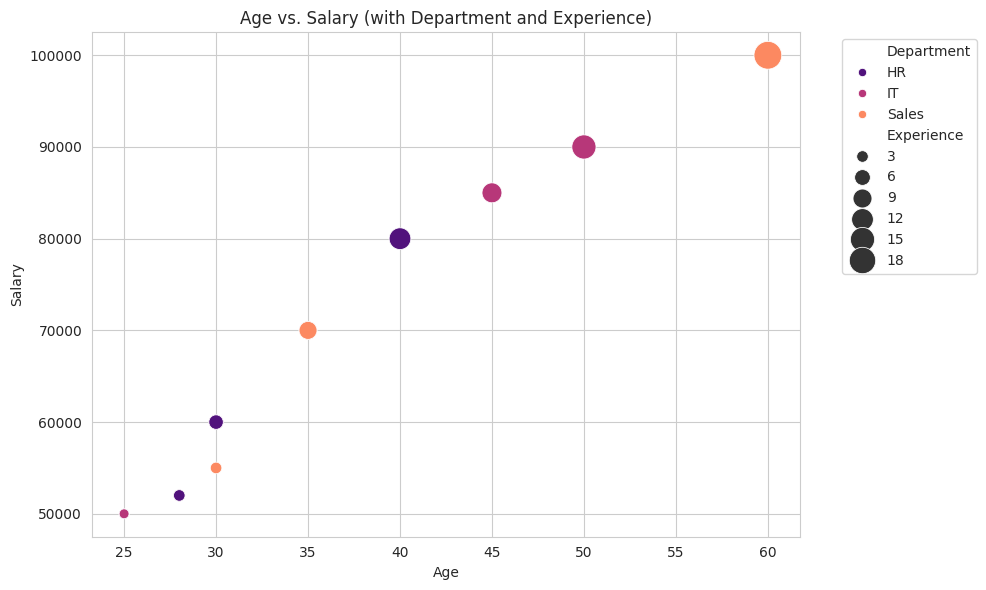

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Salary', data=df, hue='Department', size='Experience', sizes=(50, 400), palette='magma')
plt.title('Age vs. Salary (with Department and Experience)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This scatter plot visualizes the relationship between 'Age' and 'Salary', with points colored by 'Department' and sized by 'Experience'. We can generally see a positive trend: as age and experience increase, salary tends to increase. The 'Department' coloring helps to see if this trend holds true across different departments.

### Correlation Heatmap

A correlation heatmap displays the correlation coefficients between all pairs of numerical variables. Values closer to 1 or -1 indicate a strong positive or negative linear relationship, respectively, while values near 0 suggest a weak or no linear relationship.

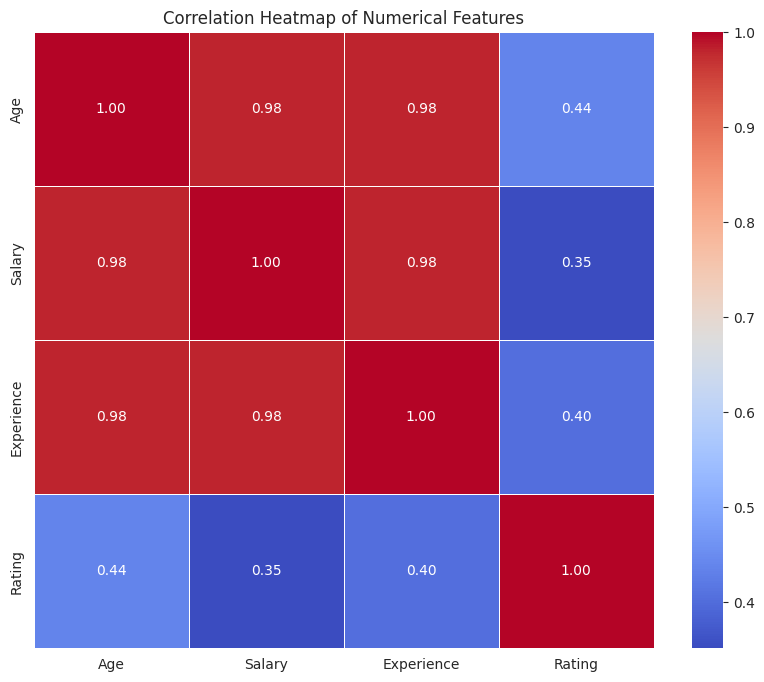

In [19]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The heatmap shows the correlation between numerical features. For instance, 'Age', 'Salary', and 'Experience' appear to have strong positive correlations with each other, which is expected as people generally earn more and gain experience as they age. 'Rating' shows a weaker correlation with the other variables.

### Pie Chart: City Distribution

A pie chart is useful for showing the proportion of each category within a whole. It's best used with a small number of categories.

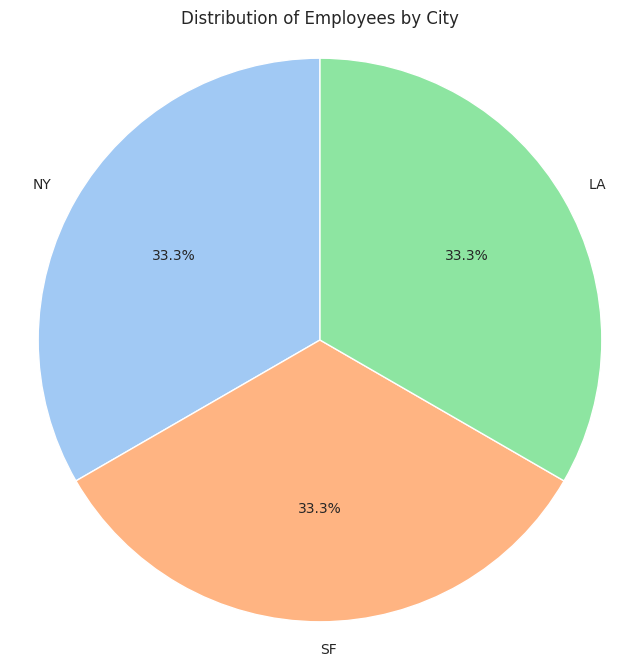

In [20]:
city_counts = df['City'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Employees by City')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This pie chart illustrates the proportional distribution of employees across different cities. It shows that the employees in our dataset are relatively evenly distributed among New York (NY), San Francisco (SF), and Los Angeles (LA).

## 6. Key Findings

Based on our data cleaning and exploratory data analysis, here are some key findings:

*   **Missing Values:** We successfully identified and imputed missing 'Age' and 'Rating' values using their respective medians.
*   **Duplicates:** Duplicate entries were found and removed, ensuring data integrity.
*   **Outliers:** Boxplots revealed potential outliers in numerical columns, though we chose not to remove them in this introductory project.
*   **Age Distribution:** The dataset primarily consists of younger individuals, with most falling within the 25-40 age range.
*   **Department Distribution:** Employees are fairly evenly distributed across the 'HR', 'IT', and 'Sales' departments.
*   **Salary Trends:** Average salaries are highest in the IT department. There's a clear positive correlation between Age, Experience, and Salary.
*   **City Distribution:** Employees are almost equally represented in NY, SF, and LA.

## 7. Business Insights

These findings can translate into actionable business insights:

*   **Recruitment & Retention:** Understanding age and salary distributions per department can inform recruitment strategies and identify areas for competitive compensation adjustments, especially in departments like IT where salaries are higher.
*   **Training & Development:** The correlation between experience and salary suggests that investing in employee development and career progression paths can be crucial for retention.
*   **Resource Allocation:** The even distribution of employees across cities and departments could indicate balanced operational structures, but further analysis might be needed to optimize resource allocation.
*   **Data Quality:** Regular checks for missing values and duplicates are essential for maintaining reliable data for decision-making.

## 8. Conclusion

This project successfully demonstrated the end-to-end process of data cleaning and exploratory data analysis using a sample dataset. We started by understanding the data's structure and contents, then meticulously cleaned it by addressing missing values and duplicates. Finally, we leveraged various visualization techniques to uncover insights into age, salary, department, and city distributions, as well as the relationships between key numerical features.

The cleaned dataset is now prepared for further, more advanced analytical tasks, such as predictive modeling or in-depth statistical hypothesis testing. This foundational work ensures that any subsequent analysis is built upon a robust and reliable data foundation.

## 9. Save the Cleaned Dataset

Finally, we'll save our cleaned DataFrame to a new CSV file. This is good practice, as it allows us to use the prepared data directly for future analysis without repeating the cleaning steps.

In [21]:
# Save the cleaned DataFrame to a new CSV file
output_filename = 'cleaned_dataset.csv'
df.to_csv(output_filename, index=False)
print(f"Cleaned dataset saved as '{output_filename}'")

Cleaned dataset saved as 'cleaned_dataset.csv'
